In [5]:
import os
import random
from pathlib import Path

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

In [6]:
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("Available GPUs:", tf.config.list_physical_devices("GPU"))
print("Experiment: ResNet50 Original — No Augmentation — No Dropout")

TensorFlow version: 2.20.0
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Experiment: ResNet50 Original — No Augmentation — No Dropout


In [7]:
dataset_path = Path(
    kagglehub.dataset_download(
        "aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented"
    )
)

image_root = dataset_path / "combined_images"

print("Dataset path:", dataset_path)
print("Image folder:", image_root)
print("Image folder exists:", image_root.exists())

Mounting files to /kaggle/input/datasets/aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented...
Dataset path: /kaggle/input/datasets/aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented
Image folder: /kaggle/input/datasets/aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented/combined_images
Image folder exists: True


In [8]:
class_to_binary = {
    "NonDemented": 0,
    "VeryMildDemented": 1,
    "MildDemented": 1,
    "ModerateDemented": 1
}

records = []

for class_name, binary_label in class_to_binary.items():
    class_folder = image_root / class_name

    for image_path in sorted(class_folder.iterdir()):
        if image_path.suffix.lower() in {".jpg", ".jpeg", ".png"}:
            records.append({
                "filepath": str(image_path),
                "original_class": class_name,
                "label": binary_label
            })

df = pd.DataFrame(records)

print("Total images:", len(df))
print("\nBinary class counts:")
print(df["label"].value_counts().sort_index())

print("\nOriginal class counts:")
print(df["original_class"].value_counts())

Total images: 44000

Binary class counts:
label
0    12800
1    31200
Name: count, dtype: int64

Original class counts:
original_class
NonDemented         12800
VeryMildDemented    11200
MildDemented        10000
ModerateDemented    10000
Name: count, dtype: int64


In [9]:
from sklearn.model_selection import train_test_split

train_df, temporary_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED
)

validation_df, test_df = train_test_split(
    temporary_df,
    test_size=0.50,
    stratify=temporary_df["label"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
validation_df = validation_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Training:", len(train_df), "images")
print(train_df["label"].value_counts().sort_index())

print("\nValidation:", len(validation_df), "images")
print(validation_df["label"].value_counts().sort_index())

print("\nTesting:", len(test_df), "images")
print(test_df["label"].value_counts().sort_index())

Training: 30800 images
label
0     8960
1    21840
Name: count, dtype: int64

Validation: 6600 images
label
0    1920
1    4680
Name: count, dtype: int64

Testing: 6600 images
label
0    1920
1    4680
Name: count, dtype: int64


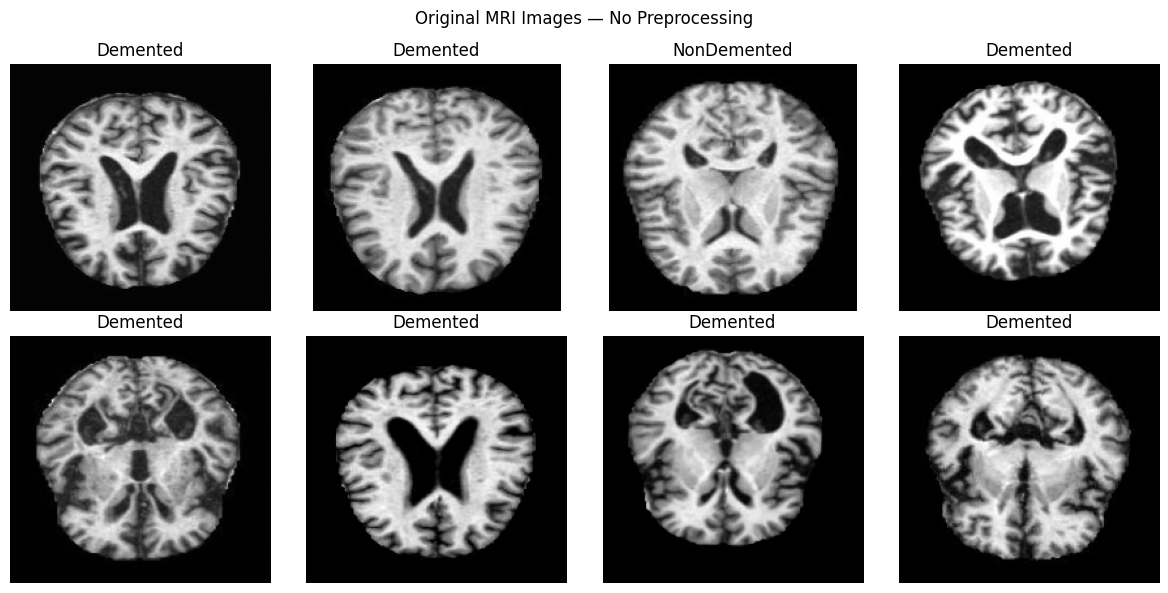

In [10]:
sample_rows = train_df.sample(
    8,
    random_state=SEED
).reset_index(drop=True)

plt.figure(figsize=(12, 6))

for index, row in sample_rows.iterrows():
    image = tf.keras.utils.load_img(
        row["filepath"],
        color_mode="grayscale"
    )

    class_name = (
        "Demented" if row["label"] == 1
        else "NonDemented"
    )

    plt.subplot(2, 4, index + 1)
    plt.imshow(image, cmap="gray")
    plt.title(class_name)
    plt.axis("off")

plt.suptitle("Original MRI Images — No Preprocessing")
plt.tight_layout()
plt.show()

In [11]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_original_image(filepath, label):
    image = tf.io.read_file(filepath)

    image = tf.io.decode_image(
        image,
        channels=3,
        expand_animations=False
    )
    image.set_shape([None, None, 3])

    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    label = tf.cast(label, tf.float32)

    return image, label


def create_original_dataset(dataframe, training=False):
    dataset = tf.data.Dataset.from_tensor_slices(
        (
            dataframe["filepath"].values,
            dataframe["label"].values
        )
    )

    if training:
        dataset = dataset.shuffle(
            buffer_size=min(len(dataframe), 10000),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_original_image,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)

    return dataset


train_dataset = create_original_dataset(train_df, training=True)
validation_dataset = create_original_dataset(validation_df)
test_dataset = create_original_dataset(test_df)

I0000 00:00:1788346052.890499      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Pixel range: 0.0 to 255.0


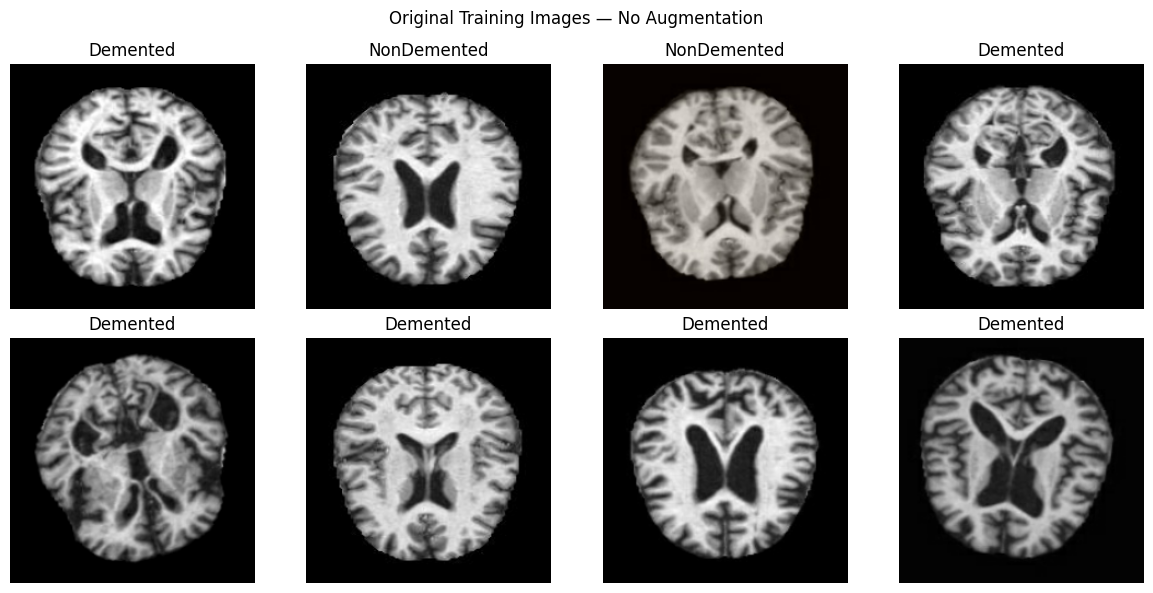

In [12]:
for images, labels in train_dataset.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Pixel range:", images.numpy().min(), "to", images.numpy().max())

    plt.figure(figsize=(12, 6))

    for index in range(8):
        plt.subplot(2, 4, index + 1)
        plt.imshow(
            tf.cast(images[index], tf.uint8)
        )

        class_name = (
            "Demented" if labels[index].numpy() == 1
            else "NonDemented"
        )

        plt.title(class_name)
        plt.axis("off")

    plt.suptitle("Original Training Images — No Augmentation")
    plt.tight_layout()
    plt.show()

In [13]:
from sklearn.utils.class_weight import compute_class_weight

MAX_EPOCHS = 30
PATIENCE = 5
LEARNING_RATE = 0.0001

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=train_df["label"]
)

class_weights = {
    0: float(weights[0]),
    1: float(weights[1])
}

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Maximum epochs:", MAX_EPOCHS)
print("Early-stopping patience:", PATIENCE)
print("Learning rate:", LEARNING_RATE)
print("Class weights:", class_weights)
print("Preprocessing: None")
print("Data augmentation: Disabled")

Image size: (224, 224)
Batch size: 32
Maximum epochs: 30
Early-stopping patience: 5
Learning rate: 0.0001
Class weights: {0: 1.71875, 1: 0.7051282051282052}
Preprocessing: None
Data augmentation: Disabled


In [15]:
resnet_base = tf.keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

resnet_base.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))

x = tf.keras.applications.resnet50.preprocess_input(inputs)
x = resnet_base(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)

outputs = tf.keras.layers.Dense(
    1,
    activation="sigmoid"
)(x)

model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="ResNet50_Original_NoAug_NoDropout"
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Total parameters:", model.count_params())
print(
    "Trainable parameters:",
    sum(
        tf.keras.backend.count_params(weight)
        for weight in model.trainable_weights
    )
)
print("ResNet50 frozen:", not resnet_base.trainable)
print("ResNet50 preprocess_input enabled: True")
print("Image enhancement: None")
print("Augmentation enabled: False")
print("Dropout enabled: False")
model.summary()

Total parameters: 23589761
Trainable parameters: 2049
ResNet50 frozen: True
ResNet50 preprocess_input enabled: True
Image enhancement: None
Augmentation enabled: False
Dropout enabled: False


Model: "ResNet50_Original_NoAug_NoDropout"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 224, 224)  │          0 │ input_layer_3[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, 224, 224)  │          0 │ input_layer_3[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_5          │ (None, 224, 224)  │          0 │ input_layer_3[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_1 (Stack)     │ (None, 224, 224,  │          0 │ get_item_3[0][0], │
│                     │ 3)                │            │ get_item_4[0][0], │
│                     │                   │            │ get_item_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 224, 224,  │          0 │ stack_1[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add_1[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │      2,049 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [16]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "/kaggle/working/resnet50_original_noaug_nodropout_best.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

In [17]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=MAX_EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
  3/963 ━━━━━━━━━━━━━━━━━━━━ 41s 44ms/step - accuracy: 0.6736 - loss: 0.8208   

I0000 00:00:1788346515.771607     145 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


963/963 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.6864 - loss: 0.6038
Epoch 1: val_loss improved from None to 0.48458, saving model to /kaggle/working/resnet50_original_noaug_nodropout_best.keras

Epoch 1: finished saving model to /kaggle/working/resnet50_original_noaug_nodropout_best.keras
963/963 ━━━━━━━━━━━━━━━━━━━━ 73s 64ms/step - accuracy: 0.7230 - loss: 0.5588 - val_accuracy: 0.7783 - val_loss: 0.4846 - learning_rate: 1.0000e-04
Epoch 2/30
963/963 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.7684 - loss: 0.4914
Epoch 2: val_loss improved from 0.48458 to 0.46787, saving model to /kaggle/working/resnet50_original_noaug_nodropout_best.keras

Epoch 2: finished saving model to /kaggle/working/resnet50_original_noaug_nodropout_best.keras
963/963 ━━━━━━━━━━━━━━━━━━━━ 51s 53ms/step - accuracy: 0.7669 - loss: 0.4902 - val_accuracy: 0.7832 - val_loss: 0.4679 - learning_rate: 1.0000e-04
Epoch 3/30
963/963 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.7766 - loss: 0.4703
Epoch 3: 

In [18]:
train_evaluation_dataset = create_original_dataset(
    train_df,
    training=False
)

best_model = tf.keras.models.load_model(
    "/kaggle/working/resnet50_original_noaug_nodropout_best.keras"
)

train_loss, train_accuracy = best_model.evaluate(
    train_evaluation_dataset,
    verbose=1
)

validation_loss, validation_accuracy = best_model.evaluate(
    validation_dataset,
    verbose=1
)

print("\nInference-mode results")
print("Training Loss:", round(train_loss, 4))
print("Training Accuracy:", round(train_accuracy, 4))
print("Validation Loss:", round(validation_loss, 4))
print("Validation Accuracy:", round(validation_accuracy, 4))
print(
    "Accuracy gap:",
    round(train_accuracy - validation_accuracy, 4)
)

963/963 ━━━━━━━━━━━━━━━━━━━━ 48s 45ms/step - accuracy: 0.8125 - loss: 0.4016
207/207 ━━━━━━━━━━━━━━━━━━━━ 11s 52ms/step - accuracy: 0.8053 - loss: 0.4061

Inference-mode results
Training Loss: 0.4016
Training Accuracy: 0.8125
Validation Loss: 0.4061
Validation Accuracy: 0.8053
Accuracy gap: 0.0072


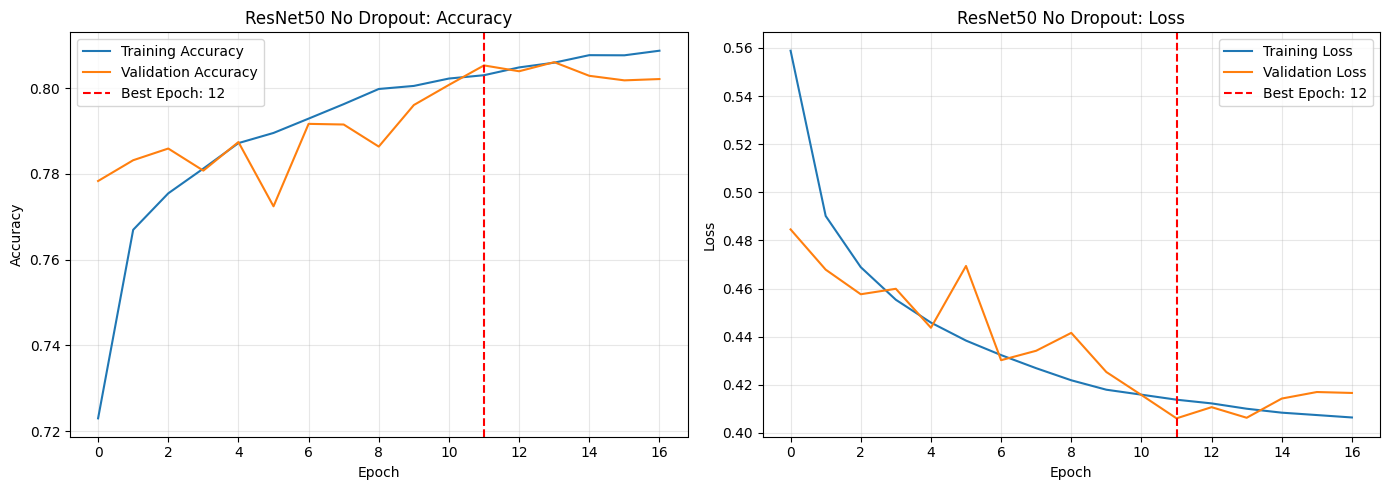

Best epoch: 12


In [19]:
history_df = pd.DataFrame(history.history)

best_epoch = history_df["val_loss"].idxmin() + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(
    history_df["accuracy"],
    label="Training Accuracy"
)
axes[0].plot(
    history_df["val_accuracy"],
    label="Validation Accuracy"
)
axes[0].axvline(
    best_epoch - 1,
    color="red",
    linestyle="--",
    label=f"Best Epoch: {best_epoch}"
)
axes[0].set_title("ResNet50 No Dropout: Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(
    history_df["loss"],
    label="Training Loss"
)
axes[1].plot(
    history_df["val_loss"],
    label="Validation Loss"
)
axes[1].axvline(
    best_epoch - 1,
    color="red",
    linestyle="--",
    label=f"Best Epoch: {best_epoch}"
)
axes[1].set_title("ResNet50 No Dropout: Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Best epoch:", best_epoch)

In [20]:
test_loss, test_accuracy = best_model.evaluate(
    test_dataset,
    verbose=1
)

print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy, 4))

207/207 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - accuracy: 0.8080 - loss: 0.4108
Test Loss: 0.4108
Test Accuracy: 0.808


In [21]:
test_probabilities = best_model.predict(
    test_dataset,
    verbose=1
).ravel()

test_predictions = (
    test_probabilities >= 0.5
).astype(int)

true_labels = test_df["label"].to_numpy()

print("Test images:", len(true_labels))
print("Probabilities:", len(test_probabilities))
print("Predictions:", len(test_predictions))

print("First probabilities:", test_probabilities[:10].round(4))
print("First predictions:", test_predictions[:10])
print("First true labels:", true_labels[:10])

207/207 ━━━━━━━━━━━━━━━━━━━━ 16s 61ms/step
Test images: 6600
Probabilities: 6600
Predictions: 6600
First probabilities: [0.9023 0.7753 0.7364 0.6669 0.9144 0.901  0.8732 0.4848 0.9772 0.944 ]
First predictions: [1 1 1 1 1 1 1 0 1 1]
First true labels: [1 1 1 1 1 1 1 0 1 1]


In [22]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

accuracy = accuracy_score(
    true_labels,
    test_predictions
)

precision = precision_score(
    true_labels,
    test_predictions
)

recall = recall_score(
    true_labels,
    test_predictions
)

f1 = f1_score(
    true_labels,
    test_predictions
)

roc_auc = roc_auc_score(
    true_labels,
    test_probabilities
)

print("Test Loss:", round(test_loss, 4))
print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-score:", round(f1, 4))
print("ROC-AUC:", round(roc_auc, 4))

print("\nClassification Report:\n")
print(
    classification_report(
        true_labels,
        test_predictions,
        target_names=["NonDemented", "Demented"],
        digits=4
    )
)

Test Loss: 0.4108
Accuracy: 0.808
Precision: 0.894
Recall: 0.8274
F1-score: 0.8594
ROC-AUC: 0.8866

Classification Report:

              precision    recall  f1-score   support

 NonDemented     0.6439    0.7609    0.6975      1920
    Demented     0.8940    0.8274    0.8594      4680

    accuracy                         0.8080      6600
   macro avg     0.7690    0.7941    0.7785      6600
weighted avg     0.8213    0.8080    0.8123      6600



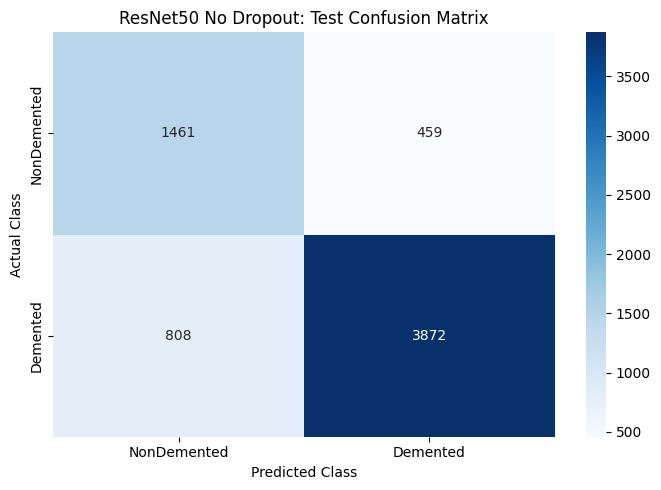

True Negatives: 1461
False Positives: 459
False Negatives: 808
True Positives: 3872


In [23]:
from sklearn.metrics import confusion_matrix

confusion = confusion_matrix(
    true_labels,
    test_predictions
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["NonDemented", "Demented"],
    yticklabels=["NonDemented", "Demented"]
)

plt.title("ResNet50 No Dropout: Test Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = confusion.ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

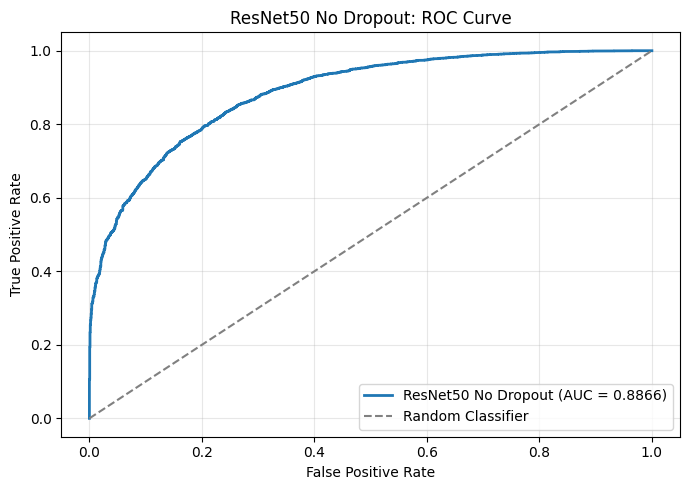

In [24]:
from sklearn.metrics import roc_curve

false_positive_rate, true_positive_rate, thresholds = roc_curve(
    true_labels,
    test_probabilities
)

plt.figure(figsize=(7, 5))

plt.plot(
    false_positive_rate,
    true_positive_rate,
    linewidth=2,
    label=f"ResNet50 No Dropout (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random Classifier"
)

plt.title("ResNet50 No Dropout: ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

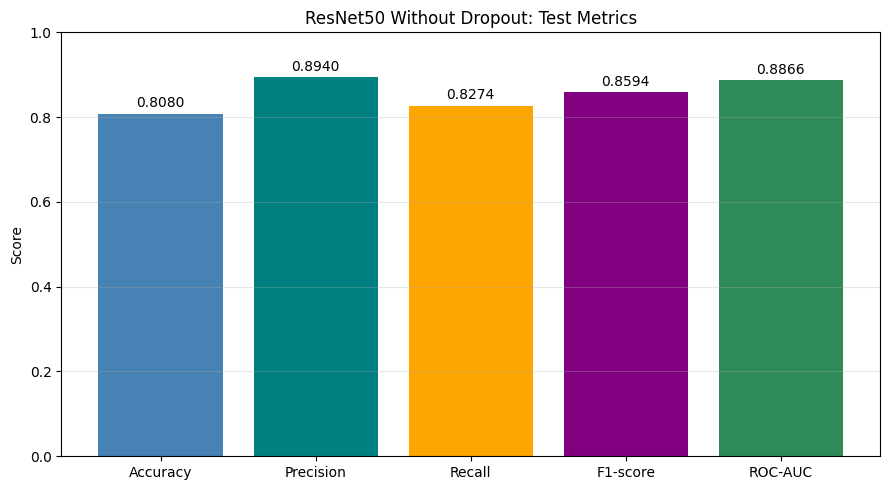

In [25]:
metric_names = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "ROC-AUC"
]

metric_values = [
    accuracy,
    precision,
    recall,
    f1,
    roc_auc
]

plt.figure(figsize=(9, 5))

bars = plt.bar(
    metric_names,
    metric_values,
    color=[
        "steelblue",
        "teal",
        "orange",
        "purple",
        "seagreen"
    ]
)

plt.ylim(0, 1)
plt.title("ResNet50 Without Dropout: Test Metrics")
plt.ylabel("Score")
plt.grid(axis="y", alpha=0.3)

for bar, value in zip(bars, metric_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.015,
        f"{value:.4f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

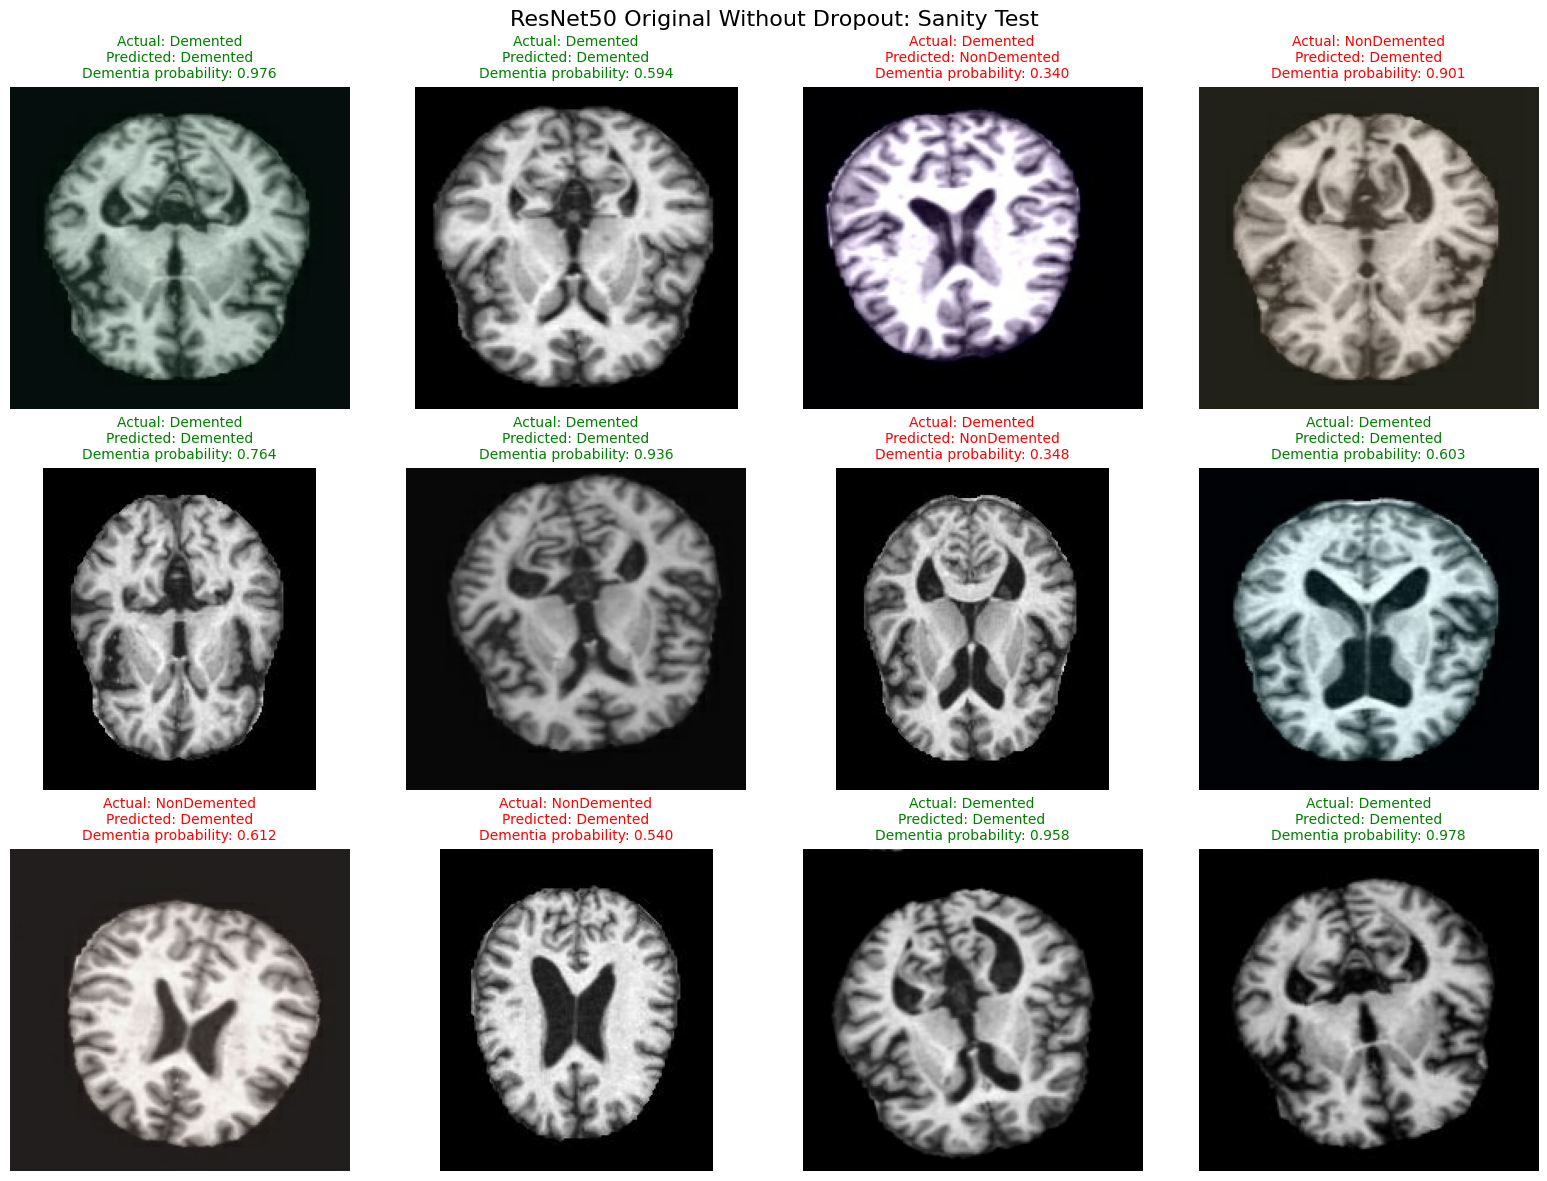

In [26]:
sample_indices = np.random.default_rng(SEED).choice(
    len(test_df),
    size=12,
    replace=False
)

plt.figure(figsize=(16, 12))

for position, index in enumerate(sample_indices, start=1):
    image = tf.io.read_file(
        test_df.iloc[index]["filepath"]
    )

    image = tf.io.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    actual = true_labels[index]
    predicted = test_predictions[index]
    probability = test_probabilities[index]

    actual_name = (
        "Demented" if actual == 1
        else "NonDemented"
    )

    predicted_name = (
        "Demented" if predicted == 1
        else "NonDemented"
    )

    title_color = (
        "green" if actual == predicted
        else "red"
    )

    plt.subplot(3, 4, position)
    plt.imshow(image)
    plt.title(
        f"Actual: {actual_name}\n"
        f"Predicted: {predicted_name}\n"
        f"Dementia probability: {probability:.3f}",
        color=title_color,
        fontsize=10
    )
    plt.axis("off")

plt.suptitle(
    "ResNet50 Original Without Dropout: Sanity Test",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [27]:
results_df = pd.DataFrame([{
    "Experiment": "ResNet50 Original NoAug NoDropout",
    "Model": "ResNet50",
    "Preprocessing": "Original",
    "Augmentation": "No",
    "Dropout Rate": 0.0,
    "Cross-Validation": "No",
    "Best Epoch": best_epoch,
    "Training Loss (Inference)": train_loss,
    "Training Accuracy (Inference)": train_accuracy,
    "Validation Loss": validation_loss,
    "Validation Accuracy": validation_accuracy,
    "Generalization Gap": train_accuracy - validation_accuracy,
    "Test Loss": test_loss,
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1,
    "ROC-AUC": roc_auc
}])

results_df.to_csv(
    "/kaggle/working/resnet50_original_noaug_nodropout_results.csv",
    index=False
)

history_df.to_csv(
    "/kaggle/working/resnet50_original_noaug_nodropout_history.csv",
    index=False
)

display(results_df.round(4))

print("Saved:")
print("- resnet50_original_noaug_nodropout_best.keras")
print("- resnet50_original_noaug_nodropout_results.csv")
print("- resnet50_original_noaug_nodropout_history.csv")

,Experiment,Model,Preprocessing,Augmentation,Dropout Rate,Cross-Validation,Best Epoch,Training Loss (Inference),Training Accuracy (Inference),Validation Loss,Validation Accuracy,Generalization Gap,Test Loss,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,ResNet50 Original NoAug NoDropout,ResNet50,Original,No,0.0,No,12,0.4016,0.8125,0.4061,0.8053,0.0072,0.4108,0.808,0.894,0.8274,0.8594,0.8866


Saved:
- resnet50_original_noaug_nodropout_best.keras
- resnet50_original_noaug_nodropout_results.csv
- resnet50_original_noaug_nodropout_history.csv
